# NQS High-Level API Showcase

This notebook is a user-facing tour of the current project-owned API surface:

- `nqs.graph`
- `nqs.hilbert`
- `nqs.operator`
- `nqs.models`
- `nqs.sampler`
- `nqs.vqs`
- `nqs.optimizer`
- `nqs.driver`
- `nqs.observables`

It is intentionally notebook-shaped: edit the parameter cells, rerun one section at a time, and compare architectures without touching the library code.

## What This Notebook Covers

1. High-level construction of lattices, Hilbert spaces, and Hamiltonians
2. Exact small-system analysis with tables and plots
3. Single-architecture VMC runs with callback-based entropy logging
4. Architecture sweeps across RBM, FFNN, and CNN
5. A separate J1-J2 example using the same public API

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'nqs').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import nqs
from demos.demo_helper import (
    build_system,
    comparison_table,
    edge_table,
    exact_observables_summary,
    half_subsystem,
    parameter_table,
    run_architecture_sweep,
    run_vmc_experiment,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 120)

display(Markdown(f"Using project root: `{PROJECT_ROOT}`"))

Using project root: `C:\Users\balin\PycharmProjects\NQS\Balint`

In [3]:
# Edit this cell to drive the rest of the notebook.

EXACT_LATTICE_SHAPE = (3, 3)
TRAINING_LATTICE_SHAPE = (3, 3)
PBC = True

TFIM_COUPLINGS = {
    'J': 1.0,
    'h': 0.8,
}

J1J2_COUPLINGS = {
    'J1': 1.0,
    'J2': 0.5,
}

TRAINING_CONFIG = {
    'learning_rate': 1e-2,
    'n_samples': 512,
    'n_discard_per_chain': 16,
    'n_chains': 8,
    'n_iter': 256,
    'callback_every': 4,
}

ARCHITECTURE_CONFIGS = {
    'RBM': {'alpha': 2},
    'FFNN': {'hidden_dims': (32, 16)},
    'CNN': {'channels': (8, 4), 'kernel_size': (3, 3)},
}

SELECTED_MODEL = 'RBM'
SELECTED_HAMILTONIAN = 'tfim'  # 'tfim' or 'j1_j2'
SELECTED_MODEL_KWARGS = dict(ARCHITECTURE_CONFIGS[SELECTED_MODEL])
SELECTED_COUPLINGS = TFIM_COUPLINGS if SELECTED_HAMILTONIAN == 'tfim' else J1J2_COUPLINGS

display(parameter_table(
    lattice_shape=TRAINING_LATTICE_SHAPE,
    hamiltonian=SELECTED_HAMILTONIAN,
    training_config=TRAINING_CONFIG,
    model_name=SELECTED_MODEL,
    model_kwargs=SELECTED_MODEL_KWARGS,
    coupling_config=SELECTED_COUPLINGS,
))

,section,parameter,value
0,system,lattice_shape,"(12, 1)"
1,system,hamiltonian,tfim
2,couplings,J,1.0
3,couplings,h,0.8
4,model,model_name,RBM
5,model,alpha,4
6,training,learning_rate,0.01
7,training,n_samples,512
8,training,n_discard_per_chain,16
9,training,n_chains,8


## High-Level Construction

Everything below is built from the public `nqs.<submodule>` namespaces rather than internal implementation modules.

In [4]:
tfim_system = build_system(
    lattice_shape=EXACT_LATTICE_SHAPE,
    pbc=PBC,
    hamiltonian='tfim',
    **TFIM_COUPLINGS,
)
j1j2_system = build_system(
    lattice_shape=EXACT_LATTICE_SHAPE,
    pbc=PBC,
    hamiltonian='j1_j2',
    **J1J2_COUPLINGS,
)

api_preview = pd.DataFrame([
    {'component': 'graph', 'example': "nqs.SquareLattice(*TRAINING_LATTICE_SHAPE, pbc=PBC)"},
    {'component': 'hilbert', 'example': "nqs.SpinHilbert(g.n_nodes)"},
    {'component': 'operator', 'example': "TFIM via nqs.Operator(...) / J1-J2 via nqs.j1_j2(hi, g, J1=..., J2=...)"},
    {'component': 'model', 'example': "nqs.RBM(alpha=2) / nqs.FFNN(...) / nqs.CNN(...)"},
    {'component': 'sampler', 'example': "nqs.NetKetSampler(hilbert=hi, ...)"},
    {'component': 'variational state', 'example': "nqs.VariationalState(model=model, params=params, sampler=sampler)"},
    {'component': 'optimizer', 'example': "nqs.Adam(learning_rate=...)"},
    {'component': 'driver', 'example': "nqs.VMC(operator=..., variational_state=..., optimizer=...)"},
    {'component': 'observables', 'example': "nqs.observables.von_neumann_entropy(...) / entropy_callback(...)"},
])

display(api_preview)
display(Markdown('### TFIM edge table'))
display(edge_table(tfim_system['graph']))
display(Markdown('### J1-J2 edge table'))
display(edge_table(j1j2_system['graph']))

pd.DataFrame([
    {
        'hamiltonian': 'TFIM',
        'n_sites': tfim_system['hilbert'].size,
        'hilbert_dimension': tfim_system['hilbert'].n_states,
        'n_terms': len(tfim_system['operator'].terms),
    },
    {
        'hamiltonian': 'J1-J2',
        'n_sites': j1j2_system['hilbert'].size,
        'hilbert_dimension': j1j2_system['hilbert'].n_states,
        'n_terms': len(j1j2_system['operator'].terms),
    },
])

,component,example
0,graph,"nqs.SquareLattice(*TRAINING_LATTICE_SHAPE, pbc=PBC)"
1,hilbert,nqs.SpinHilbert(g.n_nodes)
2,operator,"TFIM via nqs.Operator(...) / J1-J2 via nqs.j1_j2(hi, g, J1=..., J2=...)"
3,model,nqs.RBM(alpha=2) / nqs.FFNN(...) / nqs.CNN(...)
4,sampler,"nqs.NetKetSampler(hilbert=hi, ...)"
5,variational state,"nqs.VariationalState(model=model, params=params, sampler=sampler)"
6,optimizer,nqs.Adam(learning_rate=...)
7,driver,"nqs.VMC(operator=..., variational_state=..., optimizer=...)"
8,observables,nqs.observables.von_neumann_entropy(...) / entropy_callback(...)


### TFIM edge table

,bond,sites,coords
0,J1,"(0, 1)","((0, 0), (1, 0))"
1,J1,"(0, 11)","((0, 0), (11, 0))"
2,J1,"(1, 2)","((1, 0), (2, 0))"
3,J1,"(2, 3)","((2, 0), (3, 0))"
4,J1,"(3, 4)","((3, 0), (4, 0))"
5,J1,"(4, 5)","((4, 0), (5, 0))"
6,J1,"(5, 6)","((5, 0), (6, 0))"
7,J1,"(6, 7)","((6, 0), (7, 0))"
8,J1,"(7, 8)","((7, 0), (8, 0))"
9,J1,"(8, 9)","((8, 0), (9, 0))"


### J1-J2 edge table

,bond,sites,coords
0,J1,"(0, 1)","((0, 0), (1, 0))"
1,J1,"(0, 11)","((0, 0), (11, 0))"
2,J1,"(1, 2)","((1, 0), (2, 0))"
3,J1,"(2, 3)","((2, 0), (3, 0))"
4,J1,"(3, 4)","((3, 0), (4, 0))"
5,J1,"(4, 5)","((4, 0), (5, 0))"
6,J1,"(5, 6)","((5, 0), (6, 0))"
7,J1,"(6, 7)","((6, 0), (7, 0))"
8,J1,"(7, 8)","((7, 0), (8, 0))"
9,J1,"(8, 9)","((8, 0), (9, 0))"


,hamiltonian,n_sites,hilbert_dimension,n_terms
0,TFIM,12,4096,24
1,J1-J2,12,4096,24


## Exact Small-System Analysis

For the currently feasible demo size, we can build the dense Hamiltonian exactly and use the observable helpers on the exact ground state.

In [5]:
tfim_exact = exact_observables_summary(tfim_system['operator'])

exact_summary_table = pd.DataFrame([
    {
        'observable': 'ground_energy',
        'value': tfim_exact['ground_energy'],
    },
    {
        'observable': f"SvN(subsystem={half_subsystem(tfim_system['hilbert'].size)})",
        'value': tfim_exact['half_partition_von_neumann'],
    },
    {
        'observable': f"S2(subsystem={half_subsystem(tfim_system['hilbert'].size)})",
        'value': tfim_exact['half_partition_renyi2'],
    },
])

display(Markdown('### Lowest exact TFIM levels'))
display(tfim_exact['spectrum_table'])
display(Markdown('### Exact entropy summary'))
display(exact_summary_table)
display(Markdown('### Exact entropy scaling data'))
display(tfim_exact['entropy_table'])
display(Markdown('### Exact spin-spin correlation matrix'))
display(tfim_exact['correlation_matrix'])

if tfim_exact['scaling_fit'] is not None:
    display(Markdown('### Log-scaling fit for exact Renyi-2 entropy'))
    display(pd.DataFrame([tfim_exact['scaling_fit']]))

### Lowest exact TFIM levels

,level,energy
0,0,-14.021144
1,1,-14.005935
2,2,-12.791389
3,3,-12.597254
4,4,-12.597254
5,5,-11.988573
6,6,-11.979902
7,7,-11.979902


### Exact entropy summary

,observable,value
0,ground_energy,-14.021144
1,"SvN(subsystem=(0, 1, 2, 3, 4, 5))",0.736564
2,"S2(subsystem=(0, 1, 2, 3, 4, 5))",0.690749


### Exact entropy scaling data

,subsystem_size,von_neumann,renyi2
0,1,0.587129,0.507140
1,2,0.674397,0.617211
2,3,0.709409,0.660139
3,4,0.726238,0.679555
4,5,0.734196,0.688244
5,6,0.736564,0.690749


### Exact spin-spin correlation matrix

site_j,0,1,2,3,4,5,6,7,8,9,10,11
site_i,,,,,,,,,,,,
0,1.000000,0.806717,0.777993,0.768552,0.764535,0.762749,0.762230,0.762749,0.764535,0.768552,0.777993,0.806717
1,0.806717,1.000000,0.806717,0.777993,0.768552,0.764535,0.762749,0.762230,0.762749,0.764535,0.768552,0.777993
2,0.777993,0.806717,1.000000,0.806717,0.777993,0.768552,0.764535,0.762749,0.762230,0.762749,0.764535,0.768552
3,0.768552,0.777993,0.806717,1.000000,0.806717,0.777993,0.768552,0.764535,0.762749,0.762230,0.762749,0.764535
4,0.764535,0.768552,0.777993,0.806717,1.000000,0.806717,0.777993,0.768552,0.764535,0.762749,0.762230,0.762749
5,0.762749,0.764535,0.768552,0.777993,0.806717,1.000000,0.806717,0.777993,0.768552,0.764535,0.762749,0.762230
6,0.762230,0.762749,0.764535,0.768552,0.777993,0.806717,1.000000,0.806717,0.777993,0.768552,0.764535,0.762749
7,0.762749,0.762230,0.762749,0.764535,0.768552,0.777993,0.806717,1.000000,0.806717,0.777993,0.768552,0.764535
8,0.764535,0.762749,0.762230,0.762749,0.764535,0.768552,0.777993,0.806717,1.000000,0.806717,0.777993,0.768552


### Log-scaling fit for exact Renyi-2 entropy

,slope,intercept,r_squared,rmse
0,0.103125,0.527426,0.932337,0.016805


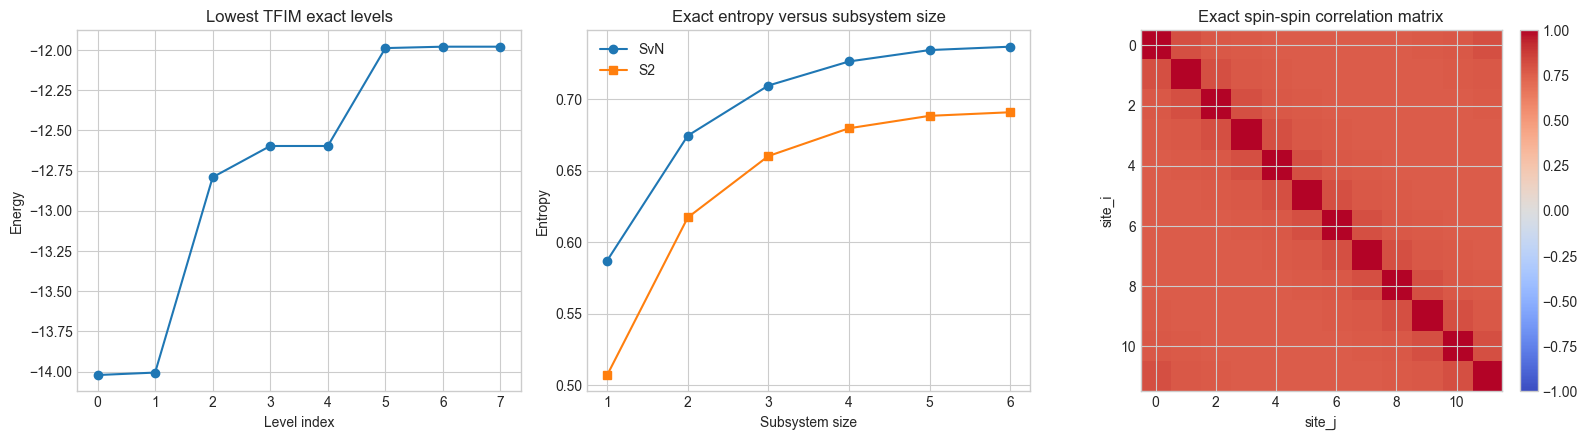

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(tfim_exact['spectrum_table']['level'], tfim_exact['spectrum_table']['energy'], marker='o')
axes[0].set_title('Lowest TFIM exact levels')
axes[0].set_xlabel('Level index')
axes[0].set_ylabel('Energy')

axes[1].plot(tfim_exact['entropy_table']['subsystem_size'], tfim_exact['entropy_table']['von_neumann'], marker='o', label='SvN')
axes[1].plot(tfim_exact['entropy_table']['subsystem_size'], tfim_exact['entropy_table']['renyi2'], marker='s', label='S2')
axes[1].set_title('Exact entropy versus subsystem size')
axes[1].set_xlabel('Subsystem size')
axes[1].set_ylabel('Entropy')
axes[1].legend()

corr_image = axes[2].imshow(tfim_exact['correlation_matrix'].values, cmap='coolwarm', vmin=-1, vmax=1)
axes[2].set_title('Exact spin-spin correlation matrix')
axes[2].set_xlabel('site_j')
axes[2].set_ylabel('site_i')
fig.colorbar(corr_image, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Single-Architecture Run

Edit `SELECTED_MODEL`, `SELECTED_MODEL_KWARGS`, and `SELECTED_HAMILTONIAN` in the parameter cell above, then rerun this section.

In [7]:
single_result = run_vmc_experiment(
    model_name=SELECTED_MODEL,
    model_kwargs=SELECTED_MODEL_KWARGS,
    lattice_shape=TRAINING_LATTICE_SHAPE,
    pbc=PBC,
    hamiltonian=SELECTED_HAMILTONIAN,
    **SELECTED_COUPLINGS,
    **TRAINING_CONFIG,
)

single_summary = pd.DataFrame([
    {
        'model': single_result['model_name'],
        'hamiltonian': SELECTED_HAMILTONIAN,
        'final_energy': single_result['final_energy'],
        'exact_ground_energy': single_result['exact']['ground_energy'],
        'energy_error': single_result['energy_error'],
        'final_renyi2_entropy': single_result['final_entropy'],
    }
])

display(Markdown('### Single run summary'))
display(single_summary)
display(Markdown('### Per-step history'))
display(single_result['history_df'])

### Single run summary

,model,hamiltonian,final_energy,exact_ground_energy,energy_error,final_renyi2_entropy
0,RBM,tfim,-13.986451,-14.021144,0.034694,0.006198


### Per-step history

,step,energy,renyi2_entropy
0,0,-3.523588,0.781160
1,1,-4.858891,NaN
2,2,-5.119125,NaN
3,3,-5.342165,NaN
4,4,-5.764572,1.536921
...,...,...,...
251,251,-13.985853,NaN
252,252,-13.985974,0.013905
253,253,-13.986094,NaN
254,254,-13.986214,NaN


In [ ]:
history_df = single_result['history_df']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history_df['step'], history_df['energy'], marker='o', label=single_result['model_name'])
axes[0].axhline(single_result['exact']['ground_energy'], linestyle='--', color='black', label='Exact ground energy')
axes[0].set_title(f"{single_result['model_name']} energy trace")
axes[0].set_xlabel('VMC step')
axes[0].set_ylabel('Energy')
axes[0].legend()

if 'renyi2_entropy' in history_df.columns:
    entropy_points = history_df.dropna(subset=['renyi2_entropy'])
    axes[1].plot(entropy_points['step'], entropy_points['renyi2_entropy'], marker='s', color='tab:green')
axes[1].set_title('Callback-logged Renyi-2 entropy')
axes[1].set_xlabel('VMC step')
axes[1].set_ylabel('Renyi-2 entropy')

plt.tight_layout()
plt.show()

## Architecture Sweep on TFIM

This cell runs RBM, FFNN, and CNN separately with the same high-level workflow and then compares the results in tables and plots.

In [8]:
architecture_results = run_architecture_sweep(
    ARCHITECTURE_CONFIGS,
    lattice_shape=TRAINING_LATTICE_SHAPE,
    pbc=PBC,
    hamiltonian='tfim',
    **TFIM_COUPLINGS,
    **TRAINING_CONFIG,
)
architecture_table = comparison_table(architecture_results)

display(architecture_table)

,model,final_energy,exact_ground_energy,energy_error,final_renyi2_entropy
0,FFNN,-18.723061,-18.722502,-0.000560,-0.000198
1,CNN,-18.718681,-18.722502,0.003821,0.001511
2,RBM,-10.944314,-18.722502,7.778188,0.000120


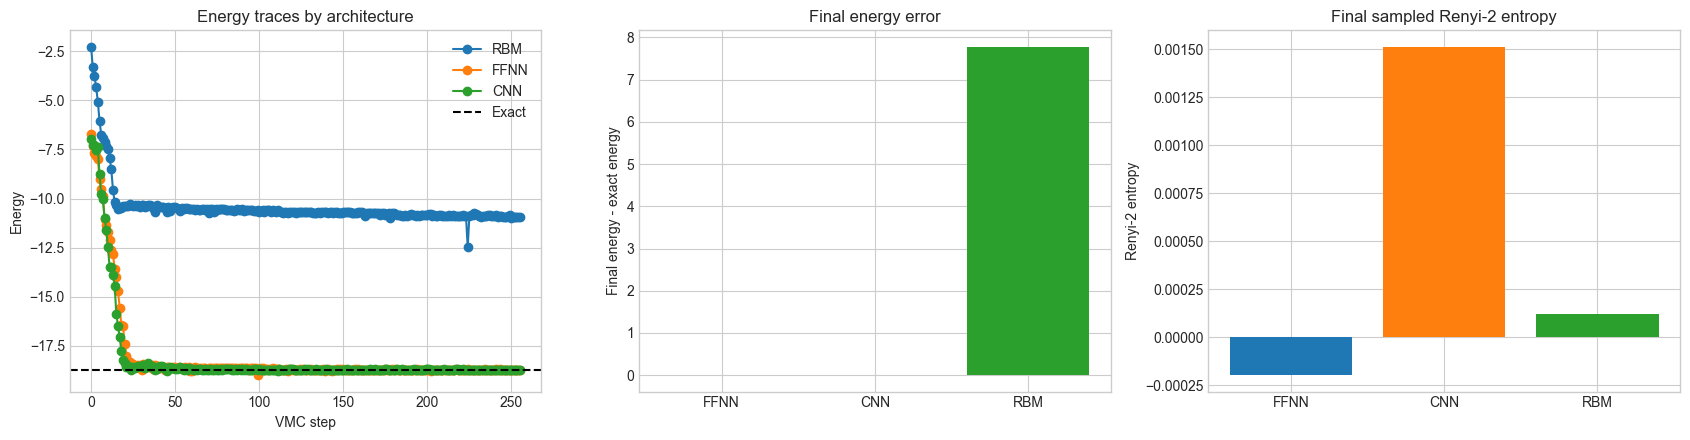

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for result in architecture_results:
    axes[0].plot(result['history_df']['step'], result['history_df']['energy'], marker='o', label=result['model_name'])
axes[0].axhline(architecture_results[0]['exact']['ground_energy'], linestyle='--', color='black', label='Exact')
axes[0].set_title('Energy traces by architecture')
axes[0].set_xlabel('VMC step')
axes[0].set_ylabel('Energy')
axes[0].legend()

axes[1].bar(architecture_table['model'], architecture_table['energy_error'], color=['tab:blue', 'tab:orange', 'tab:green'])
axes[1].set_title('Final energy error')
axes[1].set_ylabel('Final energy - exact energy')

axes[2].bar(architecture_table['model'], architecture_table['final_renyi2_entropy'], color=['tab:blue', 'tab:orange', 'tab:green'])
axes[2].set_title('Final sampled Renyi-2 entropy')
axes[2].set_ylabel('Renyi-2 entropy')

plt.tight_layout()
plt.show()

## Separate J1-J2 Run

This section uses the same high-level workflow on the J1-J2 Hamiltonian. You can keep the selected architecture from the control cell or switch it independently.

In [10]:
j1j2_exact = exact_observables_summary(j1j2_system['operator'])

display(Markdown('### Exact J1-J2 entropy scaling data'))
display(j1j2_exact['entropy_table'])

if j1j2_exact['scaling_fit'] is not None:
    display(Markdown('### Log-scaling fit for exact J1-J2 Renyi-2 entropy'))
    display(pd.DataFrame([j1j2_exact['scaling_fit']]))

### Exact J1-J2 entropy scaling data

,subsystem_size,von_neumann,renyi2
0,1,0.686010,0.679008
1,2,0.702798,0.410462
2,3,0.804828,0.441567
3,4,1.383168,1.082187


### Log-scaling fit for exact J1-J2 Renyi-2 entropy

,slope,intercept,r_squared,rmse
0,0.178572,0.511428,0.119877,0.251909


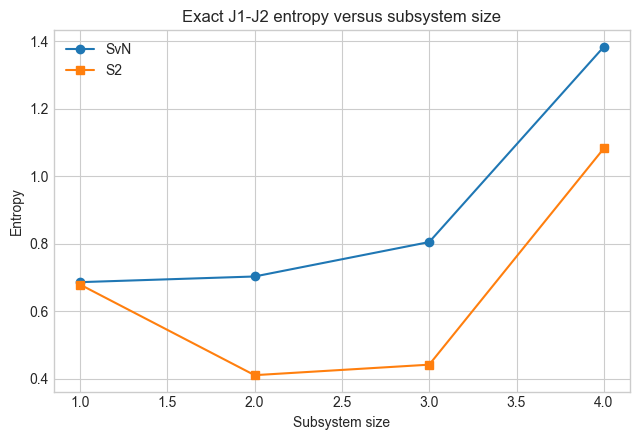

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(j1j2_exact['entropy_table']['subsystem_size'], j1j2_exact['entropy_table']['von_neumann'], marker='o', label='SvN')
ax.plot(j1j2_exact['entropy_table']['subsystem_size'], j1j2_exact['entropy_table']['renyi2'], marker='s', label='S2')
ax.set_title('Exact J1-J2 entropy versus subsystem size')
ax.set_xlabel('Subsystem size')
ax.set_ylabel('Entropy')
ax.legend()
plt.tight_layout()
plt.show()

,model,final_energy,exact_ground_energy,energy_error,final_renyi2_entropy
0,FFNN,-4.972844,-13.938003,8.96516,-0.0


,step,energy,renyi2_entropy
0,0,24.196008,0.012576
1,1,21.778098,NaN
2,2,21.020567,NaN
3,3,17.580344,NaN
4,4,15.952410,-0.008494
...,...,...,...
251,251,-4.985273,NaN
252,252,-4.985268,-0.000000
253,253,-4.985258,NaN
254,254,-4.985252,NaN


### Sampled J1-J2 NQS entropy scaling data

,subsystem_size,renyi2
0,1,-0.0
1,2,-0.0
2,3,-0.0
3,4,-0.0


### Log-scaling fit for sampled J1-J2 Renyi-2 entropy

,slope,intercept,r_squared,rmse
0,0.0,0.0,1.0,0.0


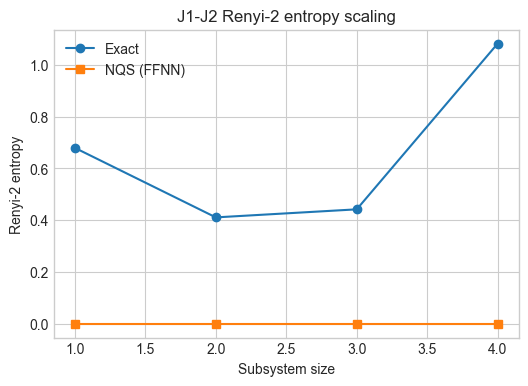

In [12]:
J1J2_MODEL = 'FFNN'
J1J2_MODEL_KWARGS = dict(ARCHITECTURE_CONFIGS[J1J2_MODEL])

j1j2_result = run_vmc_experiment(
    model_name=J1J2_MODEL,
    model_kwargs=J1J2_MODEL_KWARGS,
    lattice_shape=TRAINING_LATTICE_SHAPE,
    pbc=PBC,
    hamiltonian='j1_j2',
    **J1J2_COUPLINGS,
    **TRAINING_CONFIG,
)

display(pd.DataFrame([
    {
        'model': j1j2_result['model_name'],
        'final_energy': j1j2_result['final_energy'],
        'exact_ground_energy': j1j2_result['exact']['ground_energy'],
        'energy_error': j1j2_result['energy_error'],
        'final_renyi2_entropy': j1j2_result['final_entropy'],
    }
]))
display(j1j2_result['history_df'])

display(Markdown('### Sampled J1-J2 NQS entropy scaling data'))
display(j1j2_result['sampled_entropy_table'])

if j1j2_result['sampled_scaling_fit'] is not None:
    display(Markdown('### Log-scaling fit for sampled J1-J2 Renyi-2 entropy'))
    display(pd.DataFrame([j1j2_result['sampled_scaling_fit']]))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(j1j2_exact['entropy_table']['subsystem_size'], j1j2_exact['entropy_table']['renyi2'], marker='o', label='Exact')
ax.plot(j1j2_result['sampled_entropy_table']['subsystem_size'], j1j2_result['sampled_entropy_table']['renyi2'], marker='s', label='NQS (FFNN)')
ax.set_title('J1-J2 Renyi-2 entropy scaling')
ax.set_xlabel('Subsystem size')
ax.set_ylabel('Renyi-2 entropy')
ax.legend()
plt.show()


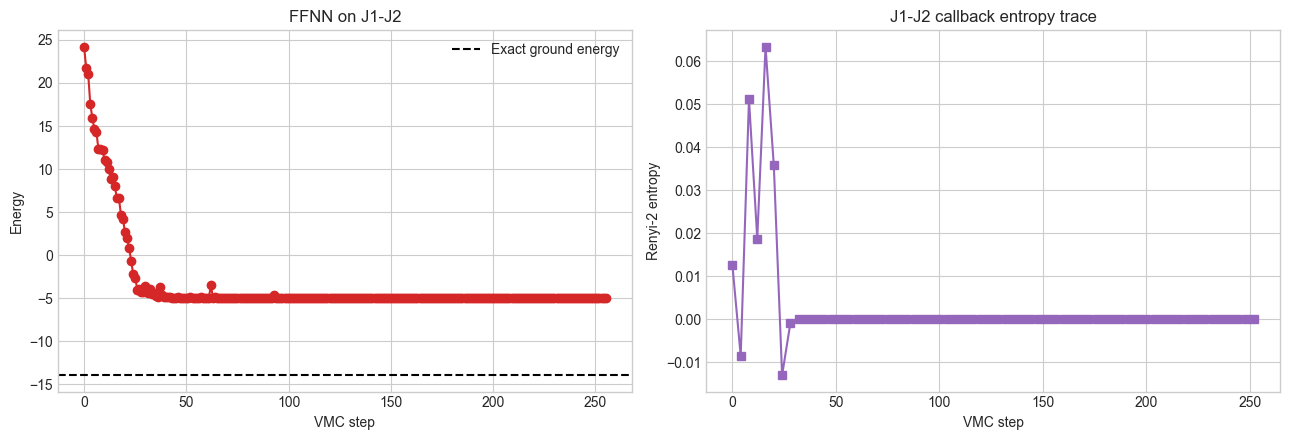

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(j1j2_result['history_df']['step'], j1j2_result['history_df']['energy'], marker='o', color='tab:red')
axes[0].axhline(j1j2_result['exact']['ground_energy'], linestyle='--', color='black', label='Exact ground energy')
axes[0].set_title(f"{j1j2_result['model_name']} on J1-J2")
axes[0].set_xlabel('VMC step')
axes[0].set_ylabel('Energy')
axes[0].legend()

if 'renyi2_entropy' in j1j2_result['history_df'].columns:
    entropy_points = j1j2_result['history_df'].dropna(subset=['renyi2_entropy'])
    axes[1].plot(entropy_points['step'], entropy_points['renyi2_entropy'], marker='s', color='tab:purple')
axes[1].set_title('J1-J2 callback entropy trace')
axes[1].set_xlabel('VMC step')
axes[1].set_ylabel('Renyi-2 entropy')

plt.tight_layout()
plt.show()

### J1-J2 Convergence Note

The weak energy convergence in this block does **not** look like a simple backend bug.

What I checked:

- the J1-J2 run uses the same expectation backend path as TFIM
- the exact `2x2` J1-J2 ground state already has mixed positive and negative amplitudes in the computational basis
- the current RBM/FFNN/CNN interface returns a single real-valued log-amplitude, so the variational state is effectively restricted to positive real amplitudes

So the likely issue is the **missing sign or phase structure in the current ansatz interface**, not a small backend wiring bug. That is not a safe notebook-side fix, so it is reported here rather than patched in the library.

## Suggested Notebook Workflow

- Change the couplings, sampler settings, or training length in the control cell.
- Edit `ARCHITECTURE_CONFIGS` to try different RBM/FFNN/CNN hyperparameters.
- Rerun the single-architecture section for one focused experiment.
- Rerun the architecture sweep section to compare all current ansatz classes under the same setup.
- Use the exact-analysis section as a small-system reference when you change the Hamiltonian parameters.